# **Portafolio de Implementación: Modelo de deep learning**

A01749075. Ameyalli Contreras Sánchez

## **Introducción**
El problema de predecir el precio de cierre del Bitcoin representa un desafío clásico dentro del análisis de series temporales financieras, caracterizado por su alta volatilidad y comportamiento no lineal. En este contexto, el uso de una red neuronal LSTM (Long Short-Term Memory) resulta especialmente adecuado, ya que este tipo de arquitectura está diseñada para capturar dependencias temporales y patrones secuenciales a largo plazo dentro de los datos históricos. Al aprovechar información pasada sobre precios, volumen y variaciones porcentuales, el modelo LSTM puede aprender dinámicas complejas del mercado que influyen en la evolución del valor del Bitcoin, ofreciendo así una herramienta predictiva más robusta y precisa que los métodos estadísticos tradicionales. Esta aproximación busca, en última instancia, estimar el precio de cierre del siguiente día con base en el comportamiento histórico reciente, apoyando la toma de decisiones en entornos financieros dinámicos.

## **Datos**

### **Librerías**

In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.regularizers import l2


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Input, Dense, Dropout, Bidirectional


### **Descripción del dataset**
El conjunto de datos utilizado corresponde al histórico de precios de Bitcoin obtenido de la plataforma Kaggle y contiene información financiera esencial que describe su comportamiento a lo largo del tiempo. Cada registro representa un punto temporal (por día, generalmente) e incluye variables como el precio de apertura (Open), el precio máximo (High), el precio mínimo (Low), el precio de cierre (Price), el volumen transaccionado (Vol) y la capitalización de mercado (Change%). Este conjunto de datos permite analizar la evolución del valor de Bitcoin y capturar sus tendencias, volatilidad y cambios abruptos en diferentes periodos.

Liga a Kaggle: https://www.kaggle.com/datasets/soham1024/bitcoin-time-series-data-till-02082020/data 

### **Carga de datos**

In [103]:
df = pd.read_csv('Bitcoin Historical Data.csv')

In [104]:
df.tail()

,Date,Price,Open,High,Low,Vol.,Change %
3664,"Jul 22, 2010",0.1,0.1,0.1,0.1,2.16K,0.00%
3665,"Jul 21, 2010",0.1,0.1,0.1,0.1,0.58K,0.00%
3666,"Jul 20, 2010",0.1,0.1,0.1,0.1,0.26K,0.00%
3667,"Jul 19, 2010",0.1,0.1,0.1,0.1,0.57K,0.00%
3668,"Jul 18, 2010",0.1,0.0,0.1,0.1,0.08K,0.00%


### **Data preprocessing**
Se realizó un proceso de limpieza para homogeneizar los valores numéricos, eliminar símbolos o unidades inconsistentes en la columna de volumen y descartar los primeros años con escasa actividad (2010–2013), de modo que el modelo se concentrara en el periodo donde el mercado comenzó a mostrar un comportamiento más representativo y útil para el entrenamiento de modelos predictivos basados en series de tiempo.

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3669 entries, 0 to 3668
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      3669 non-null   object
 1   Price     3669 non-null   object
 2   Open      3669 non-null   object
 3   High      3669 non-null   object
 4   Low       3669 non-null   object
 5   Vol.      3669 non-null   object
 6   Change %  3669 non-null   object
dtypes: object(7)
memory usage: 200.8+ KB


In [106]:
def convertir_volumen(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    # Detectar signo
    signo = -1 if valor.startswith('-') else 1
    valor = valor.replace('-', '')  # quitar signo

    # Procesar sufijos
    if 'K' in valor:
        numero = float(valor.replace('K', '')) * 1_000
    elif 'M' in valor:
        numero = float(valor.replace('M', '')) * 1_000_000
    else:
        numero = float(valor)  # ya es numérico

    return signo * numero


In [107]:
# Eliminar símbolo % 
df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

# Eliminar comas
for c in ['Price', 'Open', 'High', 'Low']:
    df[c] = df[c].astype(str).str.replace(',', '').astype(float)

# Convertir a variables numéricas
df['Vol.'] = df['Vol.'].replace('-', np.nan)
df['Vol.'] = df['Vol.'].apply(convertir_volumen)

# Convertir fecha a formato datetime y ordenar
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3669 entries, 3668 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      3669 non-null   datetime64[ns]
 1   Price     3669 non-null   float64       
 2   Open      3669 non-null   float64       
 3   High      3669 non-null   float64       
 4   Low       3669 non-null   float64       
 5   Vol.      3663 non-null   float64       
 6   Change %  3669 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 229.3 KB


In [108]:
df.head(10)

,Date,Price,Open,High,Low,Vol.,Change %
3668,2010-07-18,0.1,0.0,0.1,0.1,80.0,0.0
3667,2010-07-19,0.1,0.1,0.1,0.1,570.0,0.0
3666,2010-07-20,0.1,0.1,0.1,0.1,260.0,0.0
3665,2010-07-21,0.1,0.1,0.1,0.1,580.0,0.0
3664,2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.0
3663,2010-07-23,0.1,0.1,0.1,0.1,2400.0,0.0
3662,2010-07-24,0.1,0.1,0.1,0.1,500.0,0.0
3661,2010-07-25,0.1,0.1,0.1,0.1,1550.0,0.0
3660,2010-07-26,0.1,0.1,0.1,0.1,880.0,0.0
3659,2010-07-27,0.1,0.1,0.1,0.1,3370.0,0.0


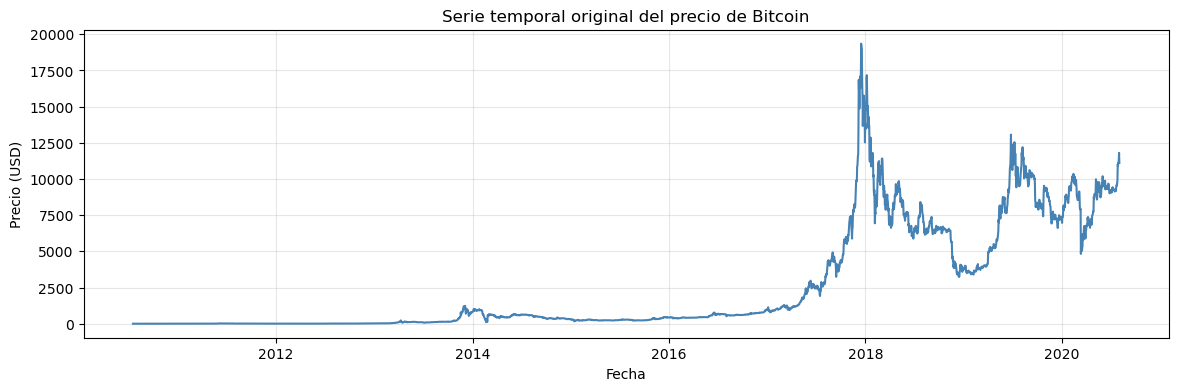

In [109]:
# Graficar la serie original completa
plt.figure(figsize=(14,4))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=1.5)

plt.title("Serie temporal original del precio de Bitcoin")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.grid(alpha=0.3)
plt.show()

In [110]:
df.shape

(3669, 7)

In [111]:
# Filtrar solo desde 2014 en adelante
df = df[df['Date'].dt.year >= 2014].reset_index(drop=True)

print(df.head(), df.tail())
print(f"Nuevas dimensiones: {df.shape}")

        Date   Price   Open    High    Low     Vol.  Change %
0 2014-01-01   815.9  805.9   829.9  771.0  10760.0      1.24
1 2014-01-02   856.9  815.9   886.2  810.5  12810.0      5.02
2 2014-01-03   884.3  856.9   888.2  839.4   9710.0      3.19
3 2014-01-04   924.7  884.3   932.2  848.3  14240.0      4.57
4 2014-01-05  1014.7  924.7  1029.9  911.4  21370.0      9.74            Date    Price     Open     High      Low      Vol.  Change %
2401 2020-07-29  11105.9  10908.4  11336.5  10771.8  576830.0      1.81
2402 2020-07-30  11096.2  11105.8  11164.4  10861.6  501140.0     -0.09
2403 2020-07-31  11333.4  11096.5  11434.8  10964.6  530950.0      2.14
2404 2020-08-01  11803.1  11333.2  11847.7  11226.1  611470.0      4.14
2405 2020-08-02  11105.8  11802.6  12061.1  10730.7  698620.0     -5.91
Nuevas dimensiones: (2406, 7)


In [112]:
# dividir en features y target
features = ['Open', 'High', 'Low', 'Vol.', 'Change %']
target = 'Price'

data = df[features + [target]].copy()
data.head()

,Open,High,Low,Vol.,Change %,Price
0,805.9,829.9,771.0,10760.0,1.24,815.9
1,815.9,886.2,810.5,12810.0,5.02,856.9
2,856.9,888.2,839.4,9710.0,3.19,884.3
3,884.3,932.2,848.3,14240.0,4.57,924.7
4,924.7,1029.9,911.4,21370.0,9.74,1014.7


In [113]:
data.shape

(2406, 6)

### **Data Split**

In [114]:
def train_valid_test_split(df):
    train_size = int(0.64 * len(df))
    val_size = int(0.16 * len(df))
    #test_size = len(features) - train_size - val_size

    train_df = df.iloc[:train_size]
    val_df   = df.iloc[train_size:train_size + val_size]
    test_df  = df.iloc[train_size + val_size:]
    
    return train_df, val_df, test_df

In [115]:
def features_target_split(df, features_list, target_col):
    X, y = df[features_list].values, df[target_col].values
    return X, y

In [116]:
train_df, val_df, test_df = train_valid_test_split(data)
print(f"> Train shape:      {train_df.shape}")
print(f"> Validation shape: {val_df.shape}")
print(f"> Test shape:       {test_df.shape}")

if (data.shape[0] == train_df.shape[0] + val_df.shape[0] + test_df.shape[0]):
    print(f"\n  Total data shape: {data.shape}")
else:
    print(f"\n  ERROR: No coincidence in data count")


> Train shape:      (1539, 6)
> Validation shape: (384, 6)
> Test shape:       (483, 6)

  Total data shape: (2406, 6)


---
### **Data Scaling**
> **CAMBIO 1: Escalar después de hacer data split**

In [119]:
# Normalización con MinMaxScaler (esencial para LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))

# Configurar scaler solo con datos de entrenamiento
train_scaled = scaler.fit_transform(train_df)

# Aplicar scaler de entrenamiento a val y test
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

# Transformar arrays escalados de vuelta a dataframes
train_scaled_df = pd.DataFrame(train_scaled, columns= features + [target])
val_scaled_df = pd.DataFrame(val_scaled, columns= features + [target])
test_scaled_df = pd.DataFrame(test_scaled, columns= features + [target])

train_scaled_df.describe()

,Open,High,Low,Vol.,Change %,Price
count,1539.000000,1539.000000,1539.000000,1539.000000,1539.000000,1539.000000
mean,0.088456,0.087559,0.087676,0.078087,0.146258,0.088727
std,0.169413,0.173184,0.163728,0.081263,0.026067,0.169658
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.012945,0.010756,0.013822,0.026944,0.142165,0.012946
50%,0.024138,0.021598,0.025408,0.056166,0.145616,0.024140
75%,0.048742,0.046924,0.049782,0.100741,0.149727,0.048763
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [120]:
# Verificar que val y test scaled hayan sido escalados con train scaler
print(f"\n============================= VALIDATION SCALED =============================\n{val_scaled_df.describe()}\n")
print(f"\n================================ TEST SCALED ================================\n{test_scaled_df.describe()}")



============================= VALIDATION SCALED =============================
             Open        High         Low        Vol.    Change %       Price
count  384.000000  384.000000  384.000000  384.000000  384.000000  384.000000
mean     0.303626    0.300077    0.306485    1.418840    0.144993    0.303172
std      0.092817    0.092487    0.092756    2.437686    0.008595    0.092579
min      0.162048    0.158403    0.165350    0.086093    0.110443    0.162063
25%      0.199266    0.195501    0.202261    0.185664    0.141524    0.199272
50%      0.327871    0.323112    0.332629    0.393094    0.145312    0.327523
75%      0.359845    0.362175    0.360960    1.057562    0.148541    0.359670
max      0.506785    0.498856    0.514470   16.660951    0.188910    0.506496


================================ TEST SCALED ================================
             Open        High         Low        Vol.    Change %       Price
count  483.000000  483.000000  483.000000  483.000000  483.00

In [121]:
# Revisar shapes
print(f">>> TRAIN SCALED:     {train_scaled.shape}")
print(f">>> VALIDATION SCALED: {val_scaled.shape}")
print(f">>> TEST SCALED:       {test_scaled.shape}")

>>> TRAIN SCALED:     (1539, 6)
>>> VALIDATION SCALED: (384, 6)
>>> TEST SCALED:       (483, 6)


In [122]:
def create_sequences(dataset, look_back=60):
    """
    Crea secuencias de 'look_back' días para predecir el siguiente.
    """
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, :-1])  # todas las columnas menos target
        y.append(dataset[i, -1])               # target = Price 
    return np.array(X), np.array(y)


look_back = 60  # número de días de historial que observa la LSTM

# Crear secuencias y separar features de target
X_train, y_train = create_sequences(train_scaled, look_back)
X_val, y_val = create_sequences(val_scaled, look_back)
X_test, y_test = create_sequences(test_scaled, look_back)

print(f"Shape X: {X_train.shape}, Shape y: {y_train.shape}")
print(f"Shape X: {X_val.shape}, Shape y: {y_val.shape}")
print(f"Shape X: {X_test.shape}, Shape y: {y_test.shape}")

Shape X: (1479, 60, 5), Shape y: (1479,)
Shape X: (324, 60, 5), Shape y: (324,)
Shape X: (423, 60, 5), Shape y: (423,)


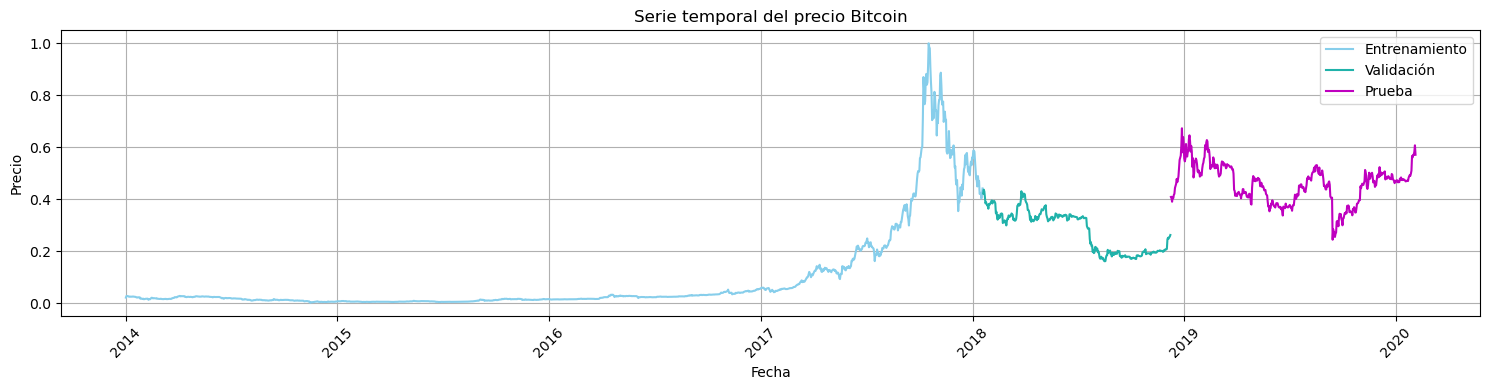

In [123]:
# Graficar train, valid y test
plt.figure(figsize=(15,4))

plt.plot(df['Date'][:len(y_train)], y_train, label='Entrenamiento', color='skyblue')
plt.plot(df['Date'][len(y_train):len(y_train)+len(y_val)], y_val, label='Validación', color='lightseagreen')
plt.plot(df['Date'][len(y_train)+len(y_val):len(y_train)+len(y_val)+len(y_test)], y_test, label='Prueba', color='m')

plt.title("Serie temporal del precio Bitcoin")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

---

## **Desarrollo del modelo: LSTM**

### **Primer modelo**
La primera arquitectura propuesta consiste en una red neuronal recurrente tipo LSTM con dos capas secuenciales de 64 unidades cada una, seguidas por una capa densa intermedia de 32 neuronas con activación ReLU y una capa de salida con una sola neurona, encargada de predecir el precio de cierre del Bitcoin. Esta configuración busca capturar las relaciones temporales entre las variables históricas (precio, apertura, máximo, mínimo y volumen) y producir una estimación precisa para el día siguiente. El modelo fue diseñado como una estructura base para evaluar la capacidad de las LSTM de modelar patrones en series financieras, priorizando una arquitectura sencilla y directa sin mecanismos de regularización adicionales.

In [20]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)
])

c:\Users\Ame Contreras\.conda\envs\deepL\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model.compile(optimizer='adam', loss='mse')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

#### **Entrenamiento**

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',     # métrica a observar
    patience=10,            # número de épocas sin mejora antes de detener
    restore_best_weights=True,  # restaura los pesos con mejor val_loss
    mode='min',
    verbose=1               # muestra mensaje cuando se detiene
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,              # máximo posible
    batch_size=32,
    callbacks=[early_stop], 
    verbose=1
)

Epoch 1/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 0.0026 - val_loss: 0.0047
Epoch 2/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 3/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 9.4640e-04 - val_loss: 0.0012
Epoch 4/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.3315e-04 - val_loss: 0.0012
Epoch 5/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 8.3232e-04 - val_loss: 0.0013
Epoch 6/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 6.3188e-04 - val_loss: 0.0015
Epoch 7/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 6.3998e-04 - val_loss: 9.5514e-04
Epoch 8/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 5.7630e-04 - val_loss: 0.0012
Epoch 9/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 5.5080e-04 - val_loss: 9.9256e-04
Epoch 10/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.5794e-04 - val_loss: 0.0025
Epoch 11/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 5.6511e-04 - val_loss: 0.0011
Epoch 12

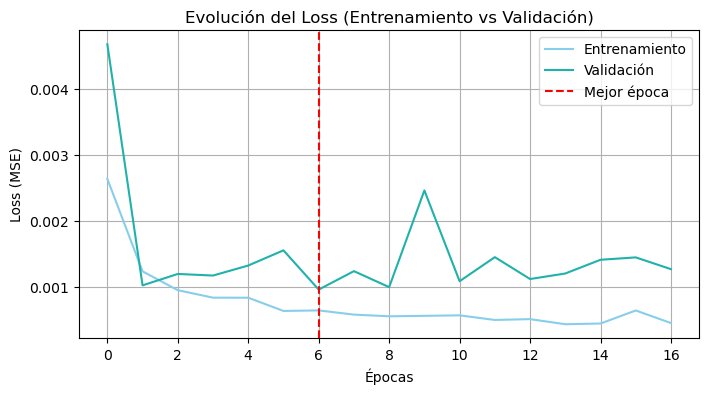

In [23]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Entrenamiento', color='skyblue')
plt.plot(history.history['val_loss'], label='Validación', color='lightseagreen')
plt.axvline(np.argmin(history.history['val_loss']), color='r', linestyle='--', label='Mejor época')
plt.title('Evolución del Loss (Entrenamiento vs Validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

#### **Validación**

In [24]:
y_pred_val = model.predict(X_val)

# Asegurar forma (n, 1)
y_pred_val = y_pred_val.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

# Crear arrays llenos de ceros con el mismo número de columnas que el scaler
n_cols = scaler.data_max_.shape[0]
inv_pred = np.zeros((len(y_pred_val), n_cols))
inv_true = np.zeros((len(y_val), n_cols))

# Colocar los valores predichos y reales en la última columna
inv_pred[:, -1] = y_pred_val[:, 0]
inv_true[:, -1] = y_val[:, 0]

# Invertir la transformación
y_pred_val_inv = scaler.inverse_transform(inv_pred)[:, -1]
y_val_inv = scaler.inverse_transform(inv_true)[:, -1]

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


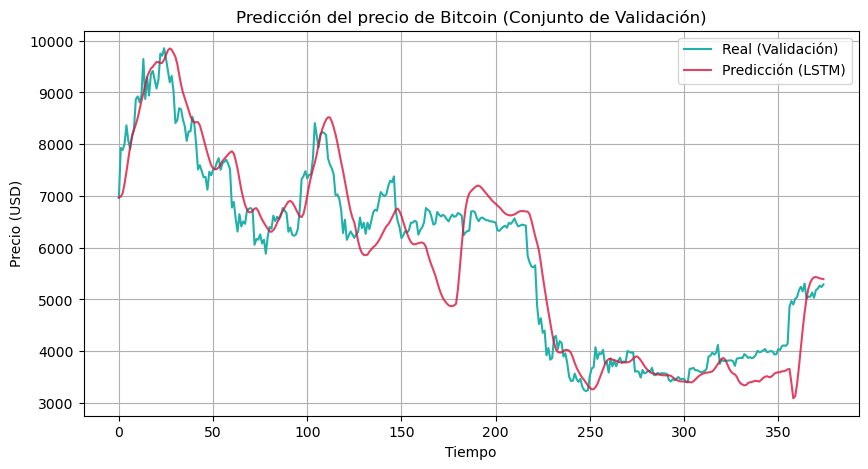

In [25]:
plt.figure(figsize=(10,5))
plt.plot(y_val_inv, label='Real (Validación)', color='lightseagreen')
plt.plot(y_pred_val_inv, label='Predicción (LSTM)', color='crimson', alpha=0.8)
plt.title('Predicción del precio de Bitcoin (Conjunto de Validación)')
plt.xlabel('Tiempo')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
mae = mean_absolute_error(y_val_inv, y_pred_val_inv)
rmse = np.sqrt(mean_squared_error(y_val_inv, y_pred_val_inv))
r2 = r2_score(y_val_inv, y_pred_val_inv)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  443.57
RMSE: 594.43
R²:   0.8842


## **Ajuste del modelo**

### **Segundo modelo**
En el segundo modelo se introdujeron ajustes estructurales orientados a mejorar el desempeño y la capacidad de generalización del modelo inicial. En el primer diseño, la red estaba compuesta por dos capas LSTM y una capa densa intermedia, sin mecanismos explícitos para controlar el sobreajuste. En la versión mejorada, se incorporaron capas Dropout con una tasa del 20% después de cada bloque LSTM, lo que permite reducir la dependencia excesiva del modelo hacia patrones específicos del conjunto de entrenamiento y fomentar una mejor generalización hacia los datos de validación y prueba. Además, se mantuvo la misma arquitectura base —dos capas LSTM con 64 unidades y una capa densa de 32 neuronas con activación ReLU—, pero ahora el modelo presenta una mayor robustez frente a la varianza y un comportamiento más estable durante el proceso de entrenamiento.

In [39]:
early_stop = EarlyStopping(
    monitor='val_loss',     # métrica a observar
    patience=10,            # número de épocas sin mejora antes de detener
    restore_best_weights=True,  # restaura los pesos con mejor val_loss
    mode='min',
    verbose=1               # muestra mensaje cuando se detiene
)

# Añadimos dropout para evitar sobreajuste
model_1 = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_1.compile(optimizer='adam', loss='mse')

model_1.summary()

c:\Users\Ame Contreras\.conda\envs\deepL\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,057 (207.25 KB)

 Trainable params: 53,057 (207.25 KB)

 Non-trainable params: 0 (0.00 B)

#### **Entrenamiento**

In [40]:
history_1 = model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,              # máximo posible
    batch_size=50,
    callbacks=[early_stop], 
    verbose=1
)

Epoch 1/200


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0081 - val_loss: 7.6521e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0014 - val_loss: 6.4235e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0015 - val_loss: 0.0032
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0015 - val_loss: 7.2616e-04
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0026 - val_loss: 6.9803e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 9.3182e-04 - val_loss: 9.4375e-04
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0010 - val_loss: 9.5350e-04
Epoch 9/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 10/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0011 - val_loss: 4.8083e-04
Epoch 11/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0019 - val_loss: 0.0010
Epoch 12/200
31/31 ━━━━━━━━━━━━━

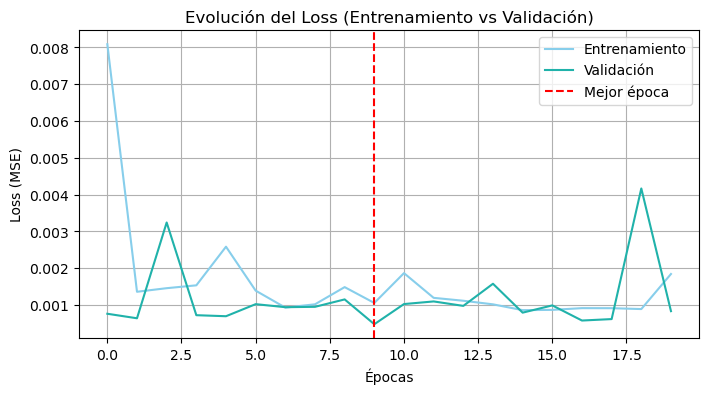

In [41]:
plt.figure(figsize=(8,4))
plt.plot(history_1.history['loss'], label='Entrenamiento', color='skyblue')
plt.plot(history_1.history['val_loss'], label='Validación', color='lightseagreen')
plt.axvline(np.argmin(history_1.history['val_loss']), color='r', linestyle='--', label='Mejor época')
plt.title('Evolución del Loss (Entrenamiento vs Validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

#### **Validación**

In [42]:
y_pred_val = model_1.predict(X_val)

# Asegurar forma (n, 1)
y_pred_val = y_pred_val.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

# Crear arrays llenos de ceros con el mismo número de columnas que el scaler
n_cols = scaler.data_max_.shape[0]
inv_pred = np.zeros((len(y_pred_val), n_cols))
inv_true = np.zeros((len(y_val), n_cols))

# Colocar los valores predichos y reales en la última columna
inv_pred[:, -1] = y_pred_val[:, 0]
inv_true[:, -1] = y_val[:, 0]

# Invertir la transformación
y_pred_val_inv = scaler.inverse_transform(inv_pred)[:, -1]
y_val_inv = scaler.inverse_transform(inv_true)[:, -1]

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


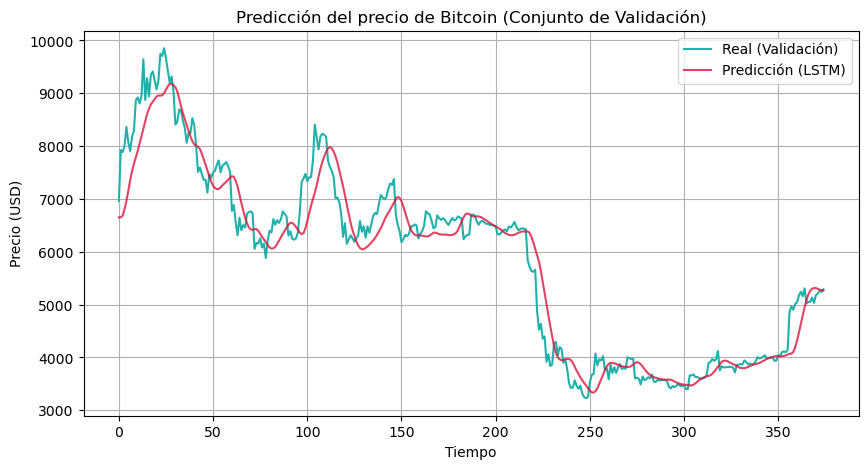

In [43]:
plt.figure(figsize=(10,5))
plt.plot(y_val_inv, label='Real (Validación)', color='lightseagreen')
plt.plot(y_pred_val_inv, label='Predicción (LSTM)', color='crimson', alpha=0.8)
plt.title('Predicción del precio de Bitcoin (Conjunto de Validación)')
plt.xlabel('Tiempo')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [44]:
mae = mean_absolute_error(y_val_inv, y_pred_val_inv)
rmse = np.sqrt(mean_squared_error(y_val_inv, y_pred_val_inv))
r2 = r2_score(y_val_inv, y_pred_val_inv)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  310.24
RMSE: 421.76
R²:   0.9417


#### **Comparación de desempeño**

Al comparar el desempeño del primer y segundo modelo sobre el conjunto de validación, se observa una mejora considerable en la precisión y la capacidad predictiva del modelo optimizado. El error medio absoluto (MAE) disminuyó de 443.57 a 310.24, y la raíz del error cuadrático medio (RMSE) pasó de 594.43 a 421.76, lo que refleja una reducción notable en la magnitud de los errores de predicción. Asimismo, el coeficiente de determinación (R²) aumentó de 0.8842 a 0.9417, evidenciando que el segundo modelo logra explicar una proporción mayor de la variabilidad del precio del Bitcoin, mostrando así un ajuste más preciso y confiable durante la validación.

---
### **Tercer Modelo**
> **CAMBIO 2: Capa Input y uso de recurrent dropout**

In [128]:
early_stop = EarlyStopping(
    monitor='val_loss',     # métrica a observar
    patience=50,            # número de épocas sin mejora antes de detener
    restore_best_weights=True,  # restaura los pesos con mejor val_loss
    mode='min',
    verbose=1               # muestra mensaje cuando se detiene
)

# CAMBIOS: ===============================================================================================
# > Incluimos una capa de Input para definir las dimensiones de la entrada en vez de usar input_shape
# > Cambiamos Dropout tradicional por recurrent_dropout en las capas LSTM
#=========================================================================================================
from tensorflow.keras.layers import TimeDistributed

model_3 = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(64, return_sequences=True, recurrent_dropout=0.2),
    TimeDistributed(Dense(64, activation='relu')),   # keeps (batch, timesteps, features)
    LSTM(64, return_sequences=False, recurrent_dropout=0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model_3.compile(optimizer='adam', loss='mse')

model_3.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 60, 64)         │         4,160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,161 (219.38 KB)

 Trainable params: 56,161 (219.38 KB)

 Non-trainable params: 0 (0.00 B)

#### **Entrenamiento**

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 114ms/step - loss: 0.0068 - val_loss: 0.0020
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0011 - val_loss: 0.0065
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 8.9577e-04 - val_loss: 0.0023
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 7.5544e-04 - val_loss: 0.0018
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 8.1388e-04 - val_loss: 0.0035
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 8.8655e-04 - val_loss: 0.0037
Epoch 9/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 7.2113e-04 - val_loss: 0.0035
Epoch 10/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 7.5244e-04 - val_loss: 0.0052
Epoch 11/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 8.2668e-04 - val_loss: 0.0026
Epoch 12/200
30/30 ━━━

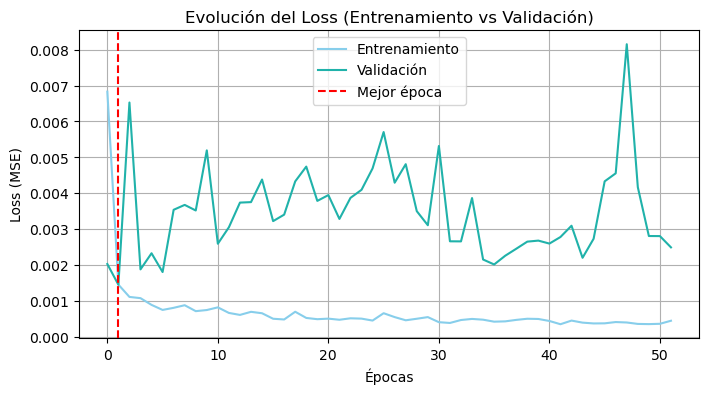

In [129]:
history_3 = model_3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,              # máximo posible
    batch_size=50,
    callbacks=[early_stop], 
    verbose=1
)
plt.figure(figsize=(8,4))
plt.plot(history_3.history['loss'], label='Entrenamiento', color='skyblue')
plt.plot(history_3.history['val_loss'], label='Validación', color='lightseagreen')
plt.axvline(np.argmin(history_3.history['val_loss']), color='r', linestyle='--', label='Mejor época')
plt.title('Evolución del Loss (Entrenamiento vs Validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

#### **Validación**

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step


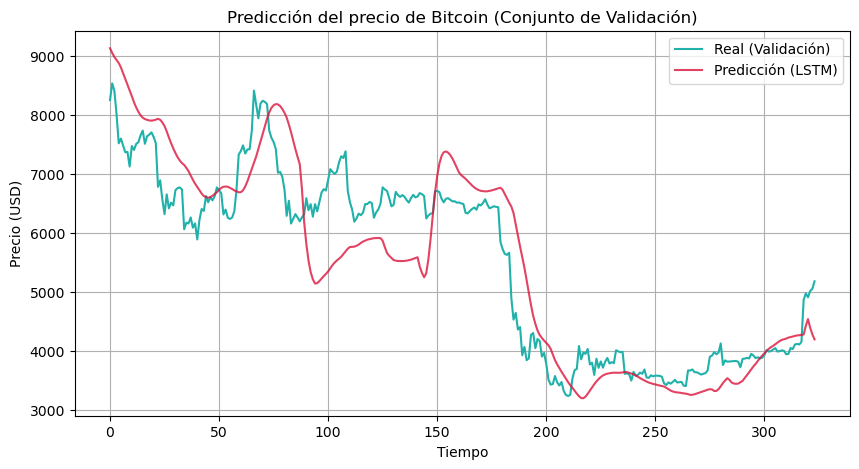

MAE:  585.00
RMSE: 734.09
R²:   0.7694


In [130]:
y_pred_val = model_3.predict(X_val)

# Asegurar forma (n, 1)
y_pred_val = y_pred_val.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

# Crear arrays llenos de ceros con el mismo número de columnas que el scaler
n_cols = scaler.data_max_.shape[0]
inv_pred = np.zeros((len(y_pred_val), n_cols))
inv_true = np.zeros((len(y_val), n_cols))

# Colocar los valores predichos y reales en la última columna
inv_pred[:, -1] = y_pred_val[:, 0]
inv_true[:, -1] = y_val[:, 0]

# Invertir la transformación
y_pred_val_inv = scaler.inverse_transform(inv_pred)[:, -1]
y_val_inv = scaler.inverse_transform(inv_true)[:, -1]
plt.figure(figsize=(10,5))
plt.plot(y_val_inv, label='Real (Validación)', color='lightseagreen')
plt.plot(y_pred_val_inv, label='Predicción (LSTM)', color='crimson', alpha=0.8)
plt.title('Predicción del precio de Bitcoin (Conjunto de Validación)')
plt.xlabel('Tiempo')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()
mae = mean_absolute_error(y_val_inv, y_pred_val_inv)
rmse = np.sqrt(mean_squared_error(y_val_inv, y_pred_val_inv))
r2 = r2_score(y_val_inv, y_pred_val_inv)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

#### **Comparación de desempeño**
Al comparar el resultado de los modelos anteriores con los obtenidos en el modelo actual, se observa que gracias a la corrección hecha en la sección de data scaling se terminó con el data leakage lo que hizo más realista el desempeño del modelo.

---
### **Cuarto Modelo**
> **CAMBIO 3: Uso de Naïve Forecasting**

In [133]:
# Naive Forecast: predicción = valor anterior

# Para validación
y_val_pred_naive = y_val[:-1]      # todo menos el último
y_val_true = y_val[1:]        # todo menos el primero

# Métricas
mae_val = mean_absolute_error(y_val_true, y_val_pred_naive)
rmse_val = np.sqrt(mean_squared_error(y_val_true, y_val_pred_naive))
r2_val = r2_score(y_val_true, y_val_pred_naive)

print("===== NAIVE FORECAST (Validación) ======")
print(f"  > MAE:  {mae_val:.2f}")
print(f"  > RMSE: {rmse_val:.2f}")
print(f"  > R²:   {r2_val:.4f}")

===== NAIVE FORECAST (Validación) ======
  > MAE:  0.01
  > RMSE: 0.01
  > R²:   0.9861


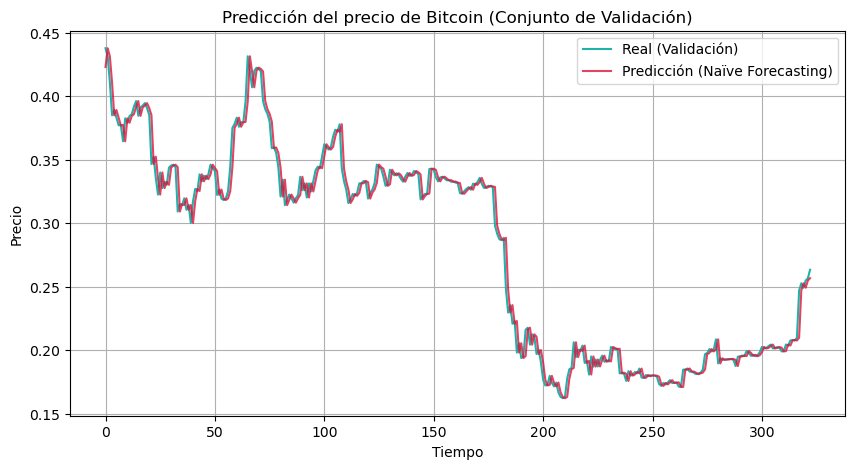

In [136]:
# GRAFICA
plt.figure(figsize=(10,5))
plt.plot(y_val_true, label='Real (Validación)', color='lightseagreen')
plt.plot(y_val_pred_naive, label='Predicción (Naïve Forecasting)', color='crimson', alpha=0.8)
plt.title('Predicción del precio de Bitcoin (Conjunto de Validación)')
plt.xlabel('Tiempo')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Para test
y_test_pred_naive = y_test[:-1]
y_test_true       = y_test[1:]

mae_test = mean_absolute_error(y_test_true, y_test_pred_naive)
rmse_test = np.sqrt(mean_squared_error(y_test_true, y_test_pred_naive))
r2_test = r2_score(y_test_true, y_test_pred_naive)

print("\n====== NAIVE FORECAST (Test) ======")
print(f"MAE:  {mae_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R²:   {r2_test:.4f}")

---
### **Quinto Modelo**
> **CAMBIO 4: Incrementar la complejidad del modelo**

> **Implementación de Hybrid Residual LSTM**

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2406 entries, 0 to 2405
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2406 non-null   datetime64[ns]
 1   Price     2406 non-null   float64       
 2   Open      2406 non-null   float64       
 3   High      2406 non-null   float64       
 4   Low       2406 non-null   float64       
 5   Vol.      2406 non-null   float64       
 6   Change %  2406 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 131.7 KB


In [139]:
# Crear variable residual en el dataframe original
df['residual'] = df['Price'].shift(-1) - df['Price']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2406 entries, 0 to 2405
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2406 non-null   datetime64[ns]
 1   Price     2406 non-null   float64       
 2   Open      2406 non-null   float64       
 3   High      2406 non-null   float64       
 4   Low       2406 non-null   float64       
 5   Vol.      2406 non-null   float64       
 6   Change %  2406 non-null   float64       
 7   residual  2405 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 150.5 KB


In [140]:
# Seleccionar features y target residua
features = ['Open', 'High', 'Low', 'Vol.', 'Change %']
target = 'residual'

data = df[features + [target]].values

In [141]:
# Split y scaling de datos
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# === Split ===
train_size = int(len(data) * 0.64)
val_size   = int(len(data) * 0.16)

train = data[:train_size]
val   = data[train_size:train_size+val_size]
test  = data[train_size+val_size:]

# === Escalar solo con train ===
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
val_scaled   = scaler.transform(val)
test_scaled  = scaler.transform(test)


In [142]:
# Convertir a secuencias 
def create_sequences(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back - 1):
        seq = dataset[i:(i+look_back), :-1]  # todas las features menos target
        label = dataset[i+look_back, -1] # target residual
        X.append(seq)
        y.append(label)
    return np.array(X), np.array(y)

look_back = 60

X_train, y_train = create_sequences(train_scaled, look_back)
X_val, y_val   = create_sequences(val_scaled, look_back)
X_test, y_test  = create_sequences(test_scaled, look_back)


Se decidión usar una capa Bidirectional LSTM en este modelo porque permite que la red analice la secuencia en dos direcciones: leyendo la información hacia adelante (pasado a futuro) y también hacia atrás (futuro a pasado) dentro de la ventana de observación. Teóricamente, esto aporta más contexto sobre cómo evoluciona la serie dentro de cada segmento, permitiendo capturar dependencias temporales que una LSTM convencional (solo forward) podría pasar por alto. En lenguaje sencillo: en lugar de aprender solo qué viene después del dato previo, la red también aprende qué había antes, lo que le da una visión más completa de los patrones internos en los datos y, en teoría, ayuda a identificar relaciones subyacentes más complejas.

In [162]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

'''model_hybrid = Sequential([
    LSTM(64, return_sequences=True, input_shape=(look_back, X_train.shape[2])),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)   # predice residual
])'''

model_hybrid = Sequential([

    # =======================
    #   Input explícito
    # =======================
    Input(shape=(look_back, X_train.shape[2])),

    # =======================
    #   Bloque 1 LSTM
    # =======================
    Bidirectional(
        LSTM(
            128,
            return_sequences=True,
            recurrent_dropout=0.2,   # dropout en conexiones recurrentes
            kernel_regularizer=l2(1e-4)
        )
    ),
    Dropout(0.2),

    # =======================
    #   Bloque 2 LSTM
    # =======================
    LSTM(
        128,
        return_sequences=True,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-4)
    ),
    Dropout(0.2),

    # =======================
    #   Bloque 3 LSTM (final)
    # =======================
    LSTM(
        64,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-4)
    ),

    # =======================
    #   Capas densas robustas
    # =======================
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),

    # =======================
    #   Salida (solo residual)
    # =======================
    Dense(1)
])

model_hybrid.compile(optimizer='adam', loss='mse')

model_hybrid.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 256)        │       137,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ (None, 60, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,017 (1.49 MB)

 Trainable params: 390,017 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

#### **Entrenamiento**

In [163]:
history_hybrid = model_hybrid.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,              # máximo posible
    batch_size=32,
    callbacks=[early_stop], 
    verbose=1
)

Epoch 1/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - loss: 0.0629 - val_loss: 0.0896
Epoch 2/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 198ms/step - loss: 0.0298 - val_loss: 0.0433
Epoch 3/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - loss: 0.0210 - val_loss: 0.0334
Epoch 4/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - loss: 0.0169 - val_loss: 0.0276
Epoch 5/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 180ms/step - loss: 0.0144 - val_loss: 0.0214
Epoch 6/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 182ms/step - loss: 0.0122 - val_loss: 0.0203
Epoch 7/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - loss: 0.0105 - val_loss: 0.0169
Epoch 8/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - loss: 0.0092 - val_loss: 0.0130
Epoch 9/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - loss: 0.0084 - val_loss: 0.0100
Epoch 10/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - loss: 0.0075 - val_loss: 0.0095
Epoch 11/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 180ms/step - loss: 0.0068 - val_loss: 0.0082
Epoch 12/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 

#### **Reconstrucción de precios reales en validación**

In [164]:
# Extraemos precios originales (sin escalar)
prices = df['Price'].values

def reconstruir_predicciones(X, pred_residuals, base_prices):
    preds = []
    for i in range(len(pred_residuals)):
        last_price = base_prices[i + look_back - 1]
        pred = last_price + pred_residuals[i]
        preds.append(pred)
    return np.array(preds)

pred_val_residual = model_hybrid.predict(X_val).flatten()
pred_test_residual = model_hybrid.predict(X_test).flatten()

# Reconstrucción final
base_prices = df['Price'].values

pred_val_price = reconstruir_predicciones(X_val, pred_val_residual, base_prices[train_size:])
pred_test_price = reconstruir_predicciones(X_test, pred_test_residual, base_prices[train_size+val_size:])

11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [166]:
# REAL
y_val_real = df['Price'].values[train_size + look_back : train_size + val_size]

# NAIVE
naive_val = df['Price'].values[train_size + look_back - 1 : train_size + val_size - 1]

# Ensure same length
min_len = min(len(y_val_real), len(pred_val_price))
y_val_real = y_val_real[:min_len]
naive_val = naive_val[:min_len]

In [167]:
# MÉTRICAS
rmse_hybrid = np.sqrt(mean_squared_error(y_val_real, pred_val_price))
rmse_naive  = np.sqrt(mean_squared_error(y_val_real, naive_val))

print("Hybrid RMSE:", rmse_hybrid)
print("Naive RMSE:", rmse_naive)

Hybrid RMSE: 179.18243075303877
Naive RMSE: 179.1582980453708


In [168]:
def mase(y_true, y_pred):
    num = np.mean(np.abs(y_true - y_pred))
    denom = np.mean(np.abs(np.diff(y_true)))
    return num / denom

print("MASE Hybrid:", mase(y_val_real, pred_val_price))
print("MASE Naive:", mase(y_val_real, naive_val))

MASE Hybrid: 0.9967822224286677
MASE Naive: 0.9969202642957964


**Conclusión comparativa Naïve VS Hybrid**

Los resultados muestran que el modelo híbrido basado en LSTM no ofrece mejoras sustanciales respecto a un enfoque naïve de persistencia. La similitud en métricas sugiere que la serie presenta baja dependencia temporal aprovechable, o que la mayor parte de su comportamiento es esencialmente aleatorio, por lo que modelos más complejos no logran extraer señales predictivas adicionales.

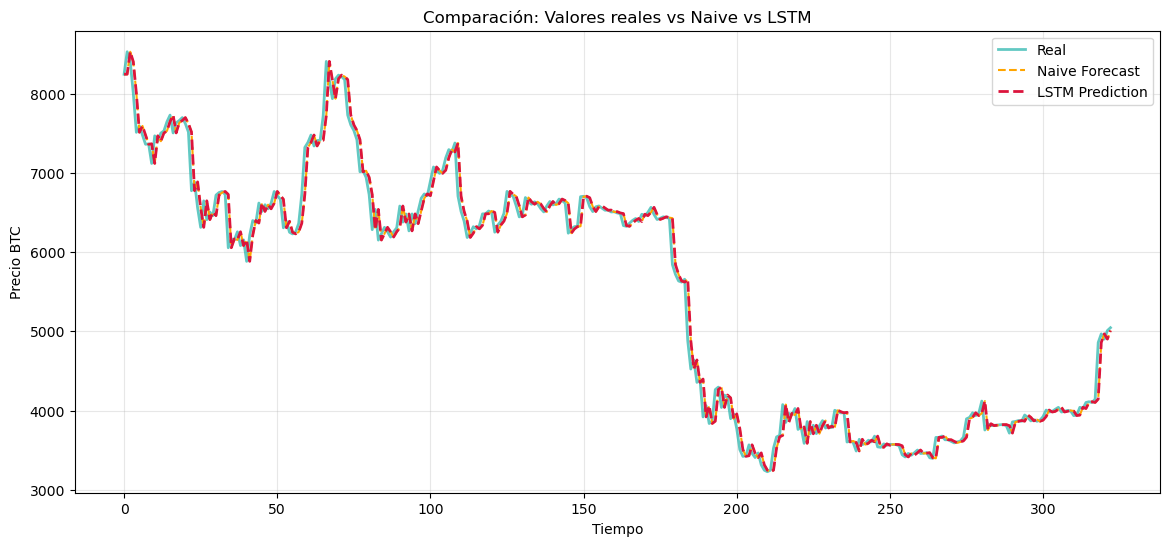

In [178]:
plt.figure(figsize=(14,6))

plt.plot(y_val_real, label='Real', linewidth=2, color="lightseagreen", alpha=0.7)
plt.plot(naive_val, label='Naive Forecast', linestyle='--', color="orange", linewidth=1.5)
plt.plot(pred_val_price, label='LSTM Prediction', linestyle='--', color="crimson", linewidth=2)

plt.title('Comparación: Valores reales vs Naive vs LSTM')
plt.xlabel('Tiempo')
plt.ylabel('Precio BTC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### **Conclusion de desempeño en datos de validación**
Los resultados finales muestran que, a pesar de utilizar una arquitectura LSTM más compleja y diseñada para capturar patrones subyacentes en la serie temporal (picos, tendencias y variaciones no lineales), el desempeño obtenido es muy similar al del método Naive Forecasting. En la gráfica puede observarse que ambas predicciones prácticamente “siguen” la trayectoria real del precio sin separación visual evidente: las curvas de Naive y LSTM casi se superponen durante todo el horizonte de validación. Este resultado tiene una explicación teórica clara: el precio de Bitcoin presenta una fuerte persistencia, es decir, el valor de mañana suele ser muy parecido al de hoy, por lo que simplemente desplazar la serie un día hacia adelante ya logra capturar gran parte de la dinámica del sistema. Ante series con este comportamiento altamente autocorrelacionado, los modelos complejos no siempre generan mejoras sustanciales, ya que tienden a aprender lo mismo que aprende el modelo ingenuo. En conclusión, aunque la LSTM incorpora mayor sofisticación y capacidad de representación, la naturaleza del propio dataset hace que un método extremadamente simple obtenga un desempeño comparable, mostrando que no siempre “más complejo” implica “mejor” cuando la estructura de la serie está dominada por una persistencia fuerte.

## **Resultados: Set de prueba**

In [180]:
# REAL
y_test_real = df['Price'].values[train_size + val_size:]

# NAIVE
naive_test = df['Price'].values[train_size + val_size - 1 : train_size + val_size - 1 + len(y_test_real)]

# Asegurar mismo length
min_len = min(len(y_test_real), len(pred_test_price))
y_test_real = y_test_real[:min_len]
naive_test = naive_test[:min_len]

# MÉTRICAS
rmse_hybrid = np.sqrt(mean_squared_error(y_test_real, pred_test_price))
rmse_naive  = np.sqrt(mean_squared_error(y_test_real, naive_test))

print("Hybrid RMSE:", rmse_hybrid)
print("Naive RMSE:", rmse_naive)

def mase(y_true, y_pred):
    num = np.mean(np.abs(y_true - y_pred))
    denom = np.mean(np.abs(np.diff(y_true)))
    return num / denom

print("\n\nMASE Hybrid:", mase(y_test_real, pred_test_price))
print("MASE Naive:", mase(y_test_real, naive_test))

Hybrid RMSE: 2441.643301804048
Naive RMSE: 376.65141092985465


MASE Hybrid: 8.38177913369474
MASE Naive: 0.9983314374573224


In [47]:
# Predicciones
y_pred = model_1.predict(X_test)

# Invertir la normalización para interpretar resultados
# (reconstruimos con el scaler original)
scaled_full = np.zeros((len(y_pred), scaled_data.shape[1]))
scaled_full[:, -1] = y_pred.flatten()
y_pred_original = scaler.inverse_transform(scaled_full)[:, -1]

scaled_full_test = np.zeros((len(y_test), scaled_data.shape[1]))
scaled_full_test[:, -1] = y_test.flatten()
y_test_original = scaler.inverse_transform(scaled_full_test)[:, -1]

# Métricas
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2 = r2_score(y_test_original, y_pred_original)
print(f"RMSE: {rmse:.2f}, R²: {r2:.3f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
RMSE: 740.29, R²: 0.768


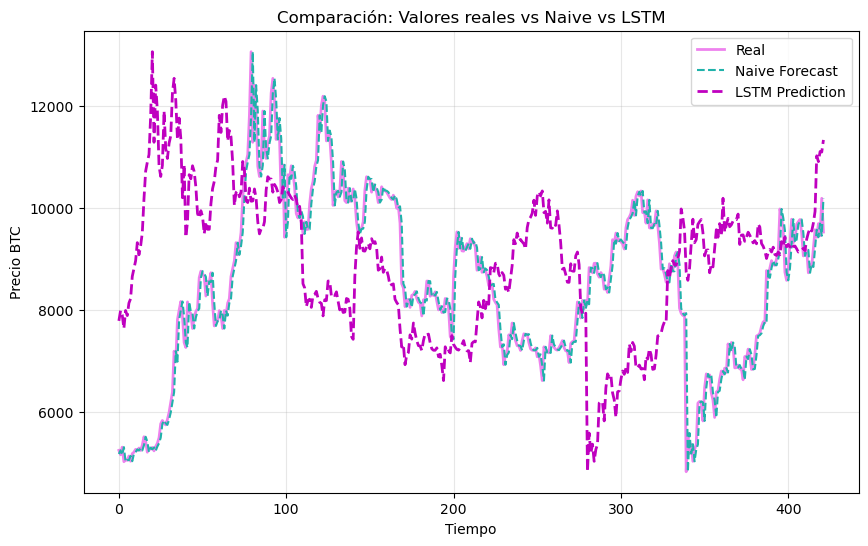

In [188]:
plt.figure(figsize=(10,6))

plt.plot(y_test_real, label='Real', linewidth=2, color="violet")
plt.plot(naive_test, label='Naive Forecast', linestyle='--', color="lightseagreen", linewidth=1.5)
plt.plot(pred_test_price, label='LSTM Prediction', linestyle='--', color="m", linewidth=2)

plt.title('Comparación: Valores reales vs Naive vs LSTM')
plt.xlabel('Tiempo')
plt.ylabel('Precio BTC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **Conclusiones de desempeño**

Los resultados indican que el modelo híbrido basado en LSTM está sobreajustando y aprendiendo ruido en lugar de patrones útiles, ya que su error en el conjunto de prueba es muy superior al modelo Naive. El Naive, con un MASE cercano a 1, muestra que la serie es altamente persistente y que predecir el siguiente valor como el último observado es prácticamente el límite óptimo de desempeño para estos datos. En cambio, el MASE del híbrido (mayor a 8) evidencia que su complejidad no aporta valor predictivo y, por el contrario, lo hace ocho veces peor que un enfoque extremadamente simple, lo que sugiere que no hay estructura temporal aprovechable más allá del lag inmediato.

## **Guardar modelo**

In [63]:
model_1.save("lstm_bitcoin_model.h5")

In [64]:
model_1.save('modelo_lstm_bitcoin.keras')

## **Aplicación**

In [104]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

# --- Función auxiliar de preprocesamiento (idéntica a la usada en entrenamiento) ---
def convertir_volumen(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    # Detectar signo
    signo = -1 if valor.startswith('-') else 1
    valor = valor.replace('-', '')  # quitar signo

    # Procesar sufijos
    if 'K' in valor:
        numero = float(valor.replace('K', '')) * 1_000
    elif 'M' in valor:
        numero = float(valor.replace('M', '')) * 1_000_000
    else:
        numero = float(valor)  # ya es numérico

    return signo * numero



def predecir_precio_nuevo(ruta_csv, modelo_path):
    # Cargar el modelo entrenado
    model = load_model(modelo_path)

    # Leer los nuevos datos
    df_new = pd.read_csv(ruta_csv)
    df_new = df_new.dropna().reset_index(drop=True)

    # Preprocesamiento coherente con el entrenamiento
    # Eliminar símbolo % 
    df_new['Change %'] = df_new['Change %'].str.replace('%', '').astype(float)

    # Eliminar comas
    for c in ['Price', 'Open', 'High', 'Low']:
        df_new[c] = df_new[c].astype(str).str.replace(',', '').astype(float)

    # Convertir a variables numéricas
    df_new['Vol.'] = df_new['Vol.'].replace('-', np.nan)
    df_new['Vol.'] = df_new['Vol.'].apply(convertir_volumen)

    # Convertir fecha a formato datetime y ordenar
    df_new['Date'] = pd.to_datetime(df_new['Date'])
    df_new.sort_values('Date', inplace=True)



    # Seleccionar solo las columnas usadas para entrenar
    features = ['Open', 'High', 'Low', 'Vol.', 'Change %']
    data = df_new[features].values


    # Escalar con el scaler original o uno nuevo (si no se proporciona)
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)

    # Crear la secuencia (últimos 60 días)
    last_sequence = scaled_data[-60:]
    X_new = np.expand_dims(last_sequence, axis=0) 

    # Realizar la predicción
    pred_scaled = model.predict(X_new)
    # Reconstruir valor original del precio
    inv_input = np.zeros((1, scaled_data.shape[1]))
    inv_input[0, 0] = pred_scaled.item()
    pred = scaler.inverse_transform(inv_input)[0, 0]

    next_date = df_new['Date'].max() + pd.Timedelta(days=1)

    print("\n\n")
    print('='*90)
    print(f"     >>> PRECIO ESTIMADO PARA EL SIGUIENTE DÍA ({next_date.date()}):  $ {pred:,.2f} USD <<<")
    print('='*90, "\n\n")
    return pred

In [105]:
prediccion = predecir_precio_nuevo('Bitcoin Historical Data.csv', 'modelo_lstm_bitcoin.keras')

c:\Users\Ame Contreras\.conda\envs\deepL\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step



     >>> PRECIO ESTIMADO PARA EL SIGUIENTE DÍA (2020-08-03):  $ 10,447.68 USD <<<


